In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

### Step1 : Load Dataset

In [2]:
df = pd.read_csv('students performance dataset/Student_Performance.csv')

### Step2: perform EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df.sample(n=4)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
5715,5,98,No,9,0,84.0
24,3,61,No,6,3,35.0
1989,5,93,Yes,8,4,80.0
4511,9,80,Yes,4,4,75.0


In [6]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Clean the data if not cleaned

### Step3: Problem Identification (Regression or Classification)

I want my model to predict Performance based on the input features i.e. Hours studied, Previous scores, Sample question papers practiced. 
So this is the Regression problem

#### The equation of Linear model (based on two input features i.e. Gender and Height)

### Y = w<sub>1</sub>X<sub>1</sub> + w<sub>2</sub>X<sub>2</sub> + ... + c        ---> eq(1)

Where,   
Y --> Predicted output  
w<sub>1</sub>, w<sub>2</sub>--> coefficients (weights for each feature)  
X<sub>1</sub>, X<sub>2</sub>--> Bias or intercept  

### Step4: Find correlation between input features and the output (numerical or graphical)

In [7]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

Note: Correlation is only computed on numerical values. In my dataset, there is non-numerical feature  
i.e. 'Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'.   

In [8]:
df.sample(n=6)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9507,8,47,No,5,0,38.0
6653,2,62,No,4,8,40.0
224,1,73,No,6,0,46.0
4413,6,78,No,8,4,66.0
5338,4,82,No,8,2,67.0
3845,4,50,Yes,6,9,34.0


In [11]:
df_new = df.drop('Extracurricular Activities', axis=1)

In [12]:
df_new

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0
...,...,...,...,...,...
9995,1,49,4,2,23.0
9996,7,64,8,5,58.0
9997,6,83,8,5,74.0
9998,9,97,7,0,95.0


In [13]:
df_new.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


<Axes: >

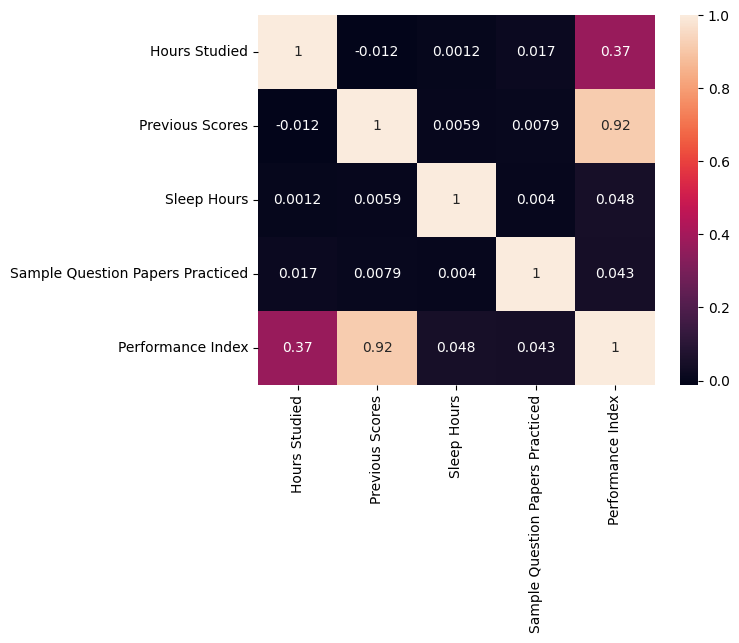

In [14]:
sns.heatmap(df_new.corr(), annot=True)

In [15]:
df_new.columns

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

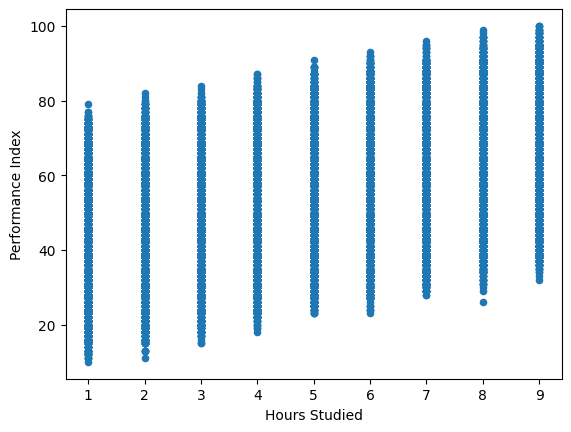

In [16]:
df_new.plot(x='Hours Studied', y='Performance Index', kind='scatter')

plt.show()

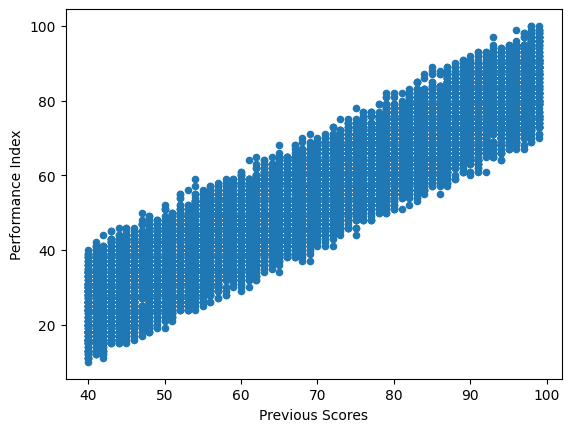

In [17]:
df.plot(x='Previous Scores', y='Performance Index', kind='scatter')

plt.show()

c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_in

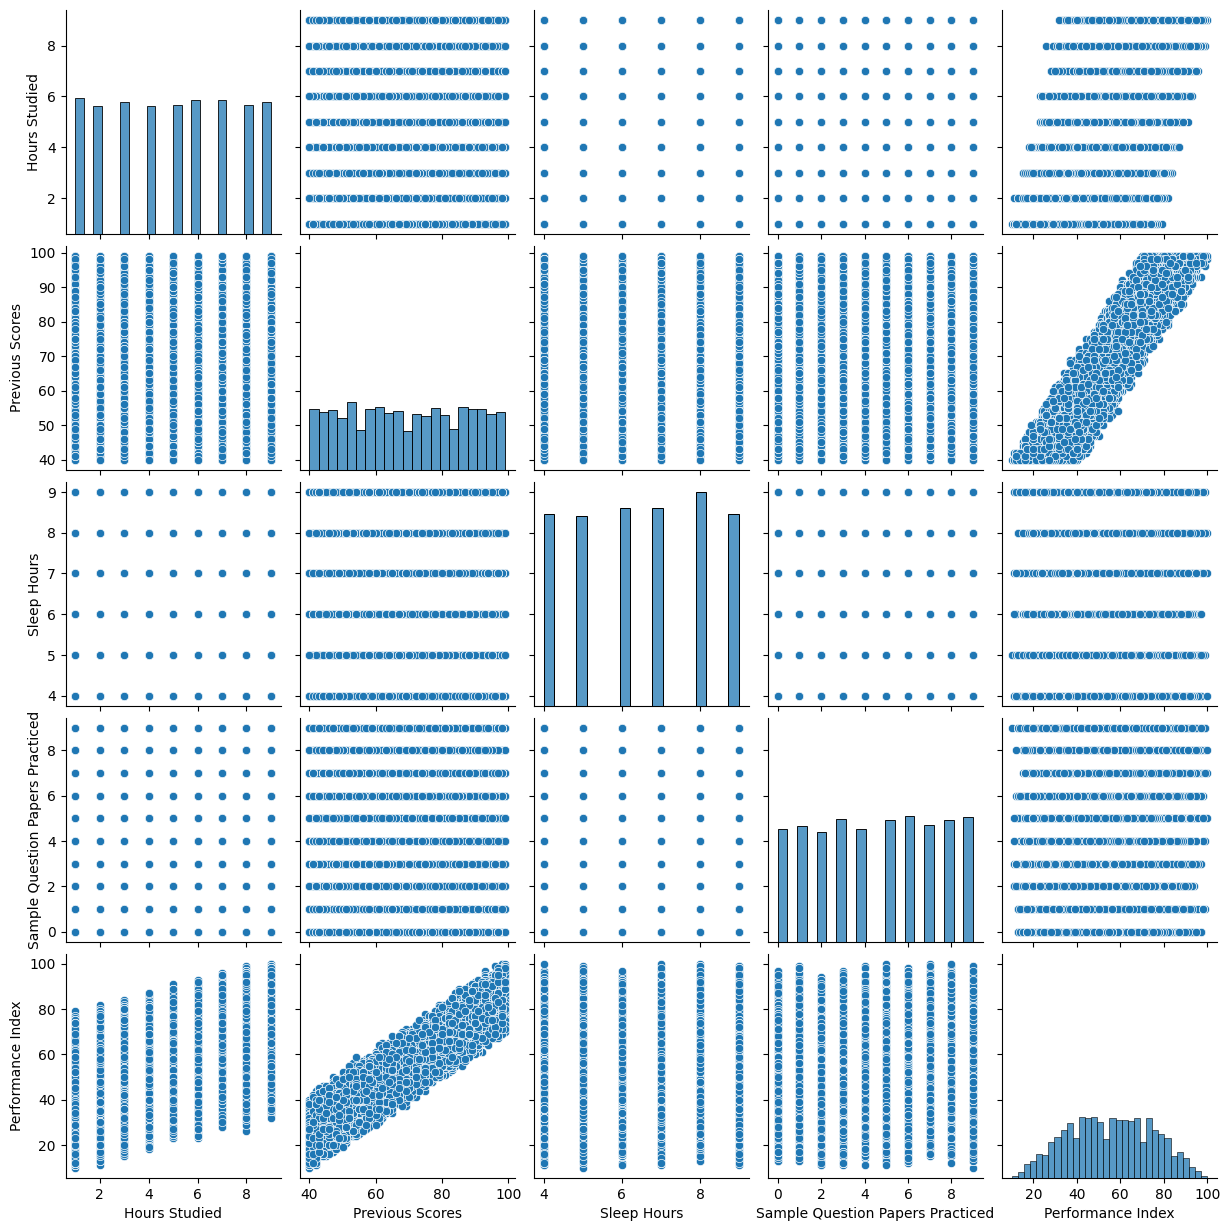

In [44]:
sns.pairplot(df_new)

### Step4: Select Model 
I have selected linear regression model

### Step5: seperate inputs and outputs 

In [18]:
df_new.columns

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [21]:
X = df_new.drop(['Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'], axis=1)

y_true = df_new['Performance Index']

In [22]:
X

,Hours Studied,Previous Scores
0,7,99
1,4,82
2,8,51
3,5,52
4,7,75
...,...,...
9995,1,49
9996,7,64
9997,6,83
9998,9,97


In [23]:
y_true

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.3, random_state=42)

In [25]:
X_train

,Hours Studied,Previous Scores
9069,4,99
2603,6,90
7738,8,57
1579,6,92
5058,6,64
...,...,...
5734,8,50
5191,4,68
5390,9,48
860,1,47


In [39]:
y_train

9069    82.0
2603    79.0
7738    50.0
1579    81.0
5058    52.0
        ... 
5734    48.0
5191    51.0
5390    44.0
860     20.0
7270    24.0
Name: Performance Index, Length: 7000, dtype: float64

### Step6: Load model

In [26]:
lr_model = LinearRegression()

In [28]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [29]:
lr_model.coef_

array([2.86449217, 1.01615225])

In [30]:
lr_model.intercept_

-29.605360900459978

#### Y = (2.8644)*(Hours Studied) + (1.0161)*(Previous Scores) - 29.6053

### Step 7: Evaluate model performance - on training data

In [31]:
y_pred = lr_model.predict(X_train)

In [32]:
print("MSE: ", mean_squared_error(y_train, y_pred))
print("RMSE: ", root_mean_squared_error(y_train, y_pred))
print("MAE: ", mean_absolute_error(y_train, y_pred))
print("R2 score: ", r2_score(y_train, y_pred))

MSE:  5.22631460035627
RMSE:  2.2861134268352195
MAE:  1.8230704909528086
R2 score:  0.9858198656093964


### Step8: Evaluate model performance - on testing data

In [33]:
X_test

,Hours Studied,Previous Scores
6252,5,69
4684,2,46
1731,7,56
4742,6,42
4521,7,53
...,...,...
8014,6,42
1074,2,60
3063,5,48
6487,3,86


In [41]:
y_test

6252    51.0
4684    20.0
1731    46.0
4742    28.0
4521    41.0
        ... 
8014    32.0
1074    40.0
3063    33.0
6487    69.0
4705    29.0
Name: Performance Index, Length: 3000, dtype: float64

In [34]:
y_pred = lr_model.predict(X_test)

In [35]:
y_pred

array([54.831605  , 22.86662681, 47.35061011, ..., 33.4924078 ,
       66.37720887, 31.27613873])

In [36]:
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("R2 score: ", r2_score(y_test, y_pred))

MSE:  5.201346140631694
RMSE:  2.2806459919574746
MAE:  1.810143749236997
R2 score:  0.9859445764337783


### Adjusted R2

$$
Adjusted R^2 = 1 - (1 - r2 score) * \frac{(n - 1)}{(n - p - 1)}
$$

Where;  

n -> no. of datapoints (row) in the dataset  
p -> no. of independent variables (features) in the model  
r2 score -> standard r2 value 

In [37]:
X_train.shape

(7000, 2)

In [38]:
r2 = r2_score(y_test, y_pred)

n, p = X_train.shape

adjusted_r2 = 1 - (1 - r2) * ((n - 1)/(n - p - 1))

print("Adjusted r2: ", adjusted_r2)

Adjusted r2:  0.9859405588766634


### Prediction on input

In [40]:
study_hours = float(input("Enter Study Hours"))
previous_scores = float(input('Enter Previous Scores'))


performance_pred = lr_model.predict([[study_hours, previous_scores]])

print("Predicted Weight: ", performance_pred)

Predicted Weight:  [60.7445539]


c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step9: Save the model


In [42]:
import pickle

In [43]:
with open('Students_performance_prediction.pkl', mode='wb') as f:
    pickle.dump(lr_model, f)

### Step10: Deplyment

In [ ]:
with open('weight_prediction_mlr.pkl', mode='rb') as f:
    loaded_model = pickle.load(f)